In [191]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns



In [192]:
df = pd.read_csv("ford.csv")
df.head()


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [193]:
df.shape

(17966, 9)

In [194]:
df.describe()


,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [195]:
df.isnull().sum()


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

EDA START FOR PRICE FEATURE


<Axes: xlabel='price', ylabel='Count'>

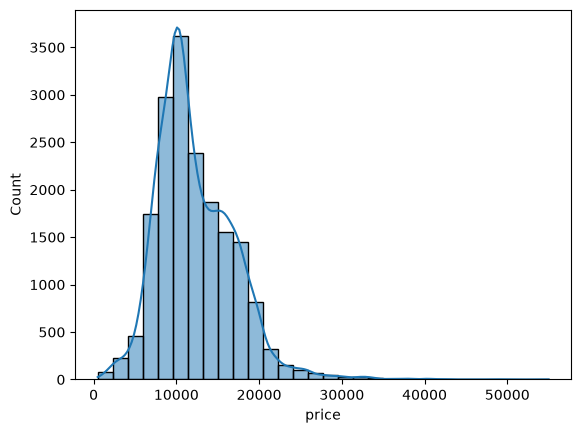

In [196]:
sns.histplot(df['price'],kde=True, bins=30)

<Axes: >

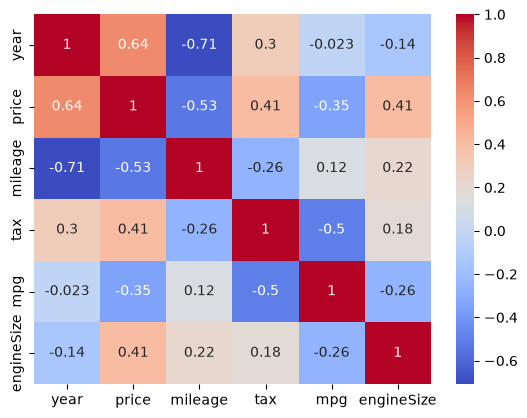

In [197]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, '1996'),
  Text(1, 0, '1998'),
  Text(2, 0, '2000'),
  Text(3, 0, '2002'),
  Text(4, 0, '2003'),
  Text(5, 0, '2004'),
  Text(6, 0, '2005'),
  Text(7, 0, '2006'),
  Text(8, 0, '2007'),
  Text(9, 0, '2008'),
  Text(10, 0, '2009'),
  Text(11, 0, '2010'),
  Text(12, 0, '2011'),
  Text(13, 0, '2012'),
  Text(14, 0, '2013'),
  Text(15, 0, '2014'),
  Text(16, 0, '2015'),
  Text(17, 0, '2016'),
  Text(18, 0, '2017'),
  Text(19, 0, '2018'),
  Text(20, 0, '2019'),
  Text(21, 0, '2020'),
  Text(22, 0, '2060')])

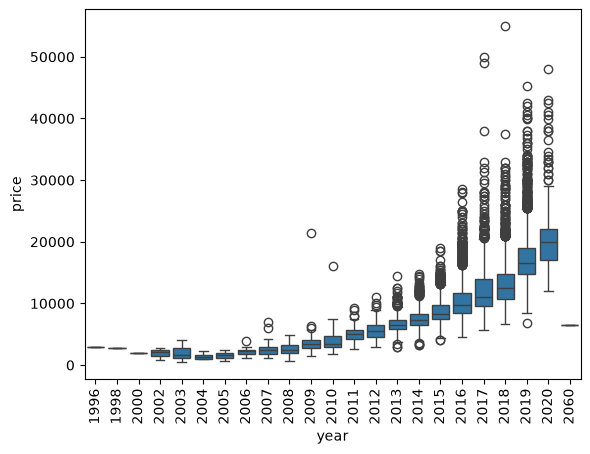

In [198]:
sns.boxplot(data=df, x='year', y='price', )
plt.xticks(rotation=90)

<Axes: xlabel='mileage', ylabel='price'>

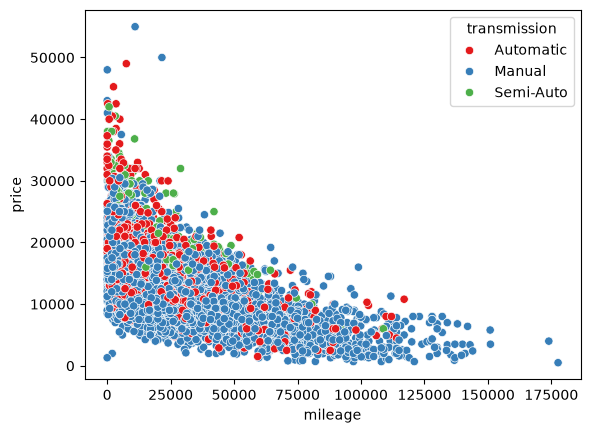

In [199]:
sns.scatterplot(data=df, x='mileage', y='price', hue='transmission', palette='Set1')

<Axes: xlabel='engineSize', ylabel='price'>

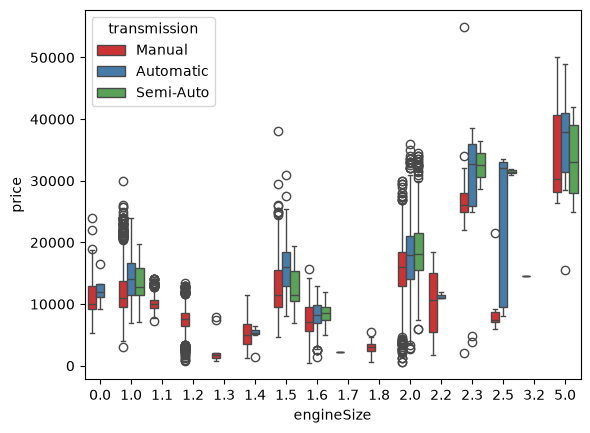

In [200]:
sns.boxplot(data=df, x='engineSize', y='price', hue='transmission', palette='Set1')

([0, 1, 2],
 [Text(0, 0, 'Automatic'), Text(1, 0, 'Manual'), Text(2, 0, 'Semi-Auto')])

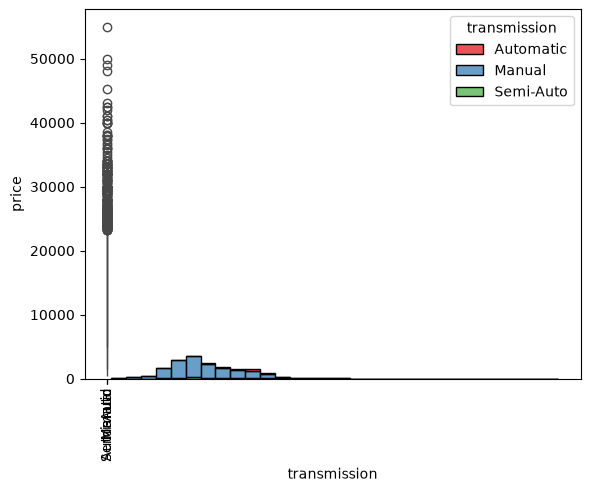

In [201]:
sns.boxplot(data=df, x='transmission', y='price', hue='transmission', palette='Set1')

sns.histplot(data=df, x='price', hue='transmission', multiple='stack', palette='Set1', bins=30)
plt.xticks(rotation=90)

AS SEEN IN THE PLOTS THE TRANSMISSION IS NOT AFFECTING THE PRICE MUCH SO WE WILL NOT TAKE TRANSMISSION IN OUR PREDICTION MODEL 


In [202]:
x = df.drop(columns=['price'])
y=df['price']


NOW CONVERT ALL VALUES INTO NUMERICAL VALUES 


In [203]:
x_one_encode = pd.get_dummies(x,columns =['transmission', 'model', 'fuelType'], drop_first=True,dtype=int  )
x_one_encode

,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2017,12456,150,57.7,1.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2019,10460,145,40.3,1.5,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17962,2014,40700,30,57.7,1.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
17963,2015,7010,20,67.3,1.6,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [204]:
from sklearn.preprocessing import LabelEncoder

columns_to_encode = ['transmission', 'model', 'fuelType']

xlabel = x.copy()

for col in columns_to_encode:
    encoder = LabelEncoder()
    xlabel[col] = encoder.fit_transform(xlabel[col].astype(str))



In [205]:
xlabel.head()


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [206]:
xlabel['model'].value_counts()

model
5     6557
6     4588
13    2225
2     1143
1      543
12     531
14     526
0      355
18     296
9      247
8      228
3      208
11     199
16      80
21      69
10      59
15      57
20      33
7       16
19       2
17       1
4        1
22       1
23       1
Name: count, dtype: int64

In [207]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg',]
scaler = StandardScaler()
x_one_encode[numeric_features] = scaler.fit_transform(x_one_encode[numeric_features])   

x_one_encode.head()


,year,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,model_ C-MAX,model_ EcoSport,model_ Edge,...,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [208]:
xlabel.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

In [209]:
xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scaler.fit_transform(xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

xlabel.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386


In [210]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

xtrain, xtest, ytrain, ytest = train_test_split(x_one_encode , y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(xtrain, ytrain)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 2183.48,-1308.47, -67.34,..., 9396.95, 931.94, -184.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.055e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [211]:
ypred = model.predict(xtest)
ypred = np.round(ypred, 2)
ypred 

array([ 6644.59,  9190.94,  9815.67, ..., 30065.02,  9629.27, 15117.01],
      shape=(3594,))

In [212]:
ytest

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
7731     22000
11655    13699
10536    24979
11885    10500
4032     19718
Name: price, Length: 3594, dtype: int64

In [213]:
r2 = r2_score(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
print(r2, mse)

0.8458422254102917 3454992.0109685035


In [214]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

xtrain, xtest, ytrain, ytest = train_test_split(xlabel , y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(xtrain, ytrain)

ypred = model2.predict(xtest)
ypred = np.round(ypred, 2)
ypred 
ytest

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
7731     22000
11655    13699
10536    24979
11885    10500
4032     19718
Name: price, Length: 3594, dtype: int64

In [215]:
r2 = r2_score(ytest, ypred)
r2 = np.round(r2, 2)
mse = mean_squared_error(ytest, ypred)
mse = np.round(mse, 2)
print(r2, mse)

0.74 5903593.41
